**PERÍODO ACADÉMICO:** 2026-A  
**ASIGNATURA:** ICCD412 Métodos Numéricos  
**GRUPO:** GR2  
**TIPO DE INSTRUMENTO:** PROYECTO
**FECHA DE ENTREGA LÍMITE:** 03/07/2026  
**ALUMNO:** Jose Pallares, Jhosua Saa, Erick Toapanta.


### Etapa 1: Tratamiento de Datos

En esta primera etapa, preparamos el entorno de trabajo aislando la ventana temporal estricta de interés (octubre 2019 - octubre 2024) y limpiando el ruido a nivel de sistema para garantizar cálculos numéricos estables en las fases posteriores.

**Los desafíos y decisiones identificados son:**
* **Filtrado Temporal:** Se aísla el periodo utilizando máscaras lógicas en Pandas.
* **Estandarización Numérica:** Se limitan los precios a 8 decimales (`round(8)`) para mitigar errores de redondeo en operaciones matriciales de punto flotante.
* **Espacio de Entrada Discreto ($t$):** Se genera la variable independiente $t \in [0, n-1]$ que representa los días de operación bursátil transcurridos, evitando desbordamientos numéricos por el uso de fechas crudas en polinomios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

#@title Etapa 1: Tratamiento de Datos
fecha_inicio_usuario = "2019-10-01" #@param {type:"date"}
fecha_fin_usuario = "2024-10-31" #@param {type:"date"}

def tratamiento_datos(dataset_path):
    try:
        df_total = pd.read_csv(dataset_path)
        df_total['Date'] = pd.to_datetime(df_total['Date'])

        print("... INFORMACION DEL DATASET CARGADO")
        print(f"Inicio del registro histórico: {df_total['Date'].min().date()}")
        print(f"Fin del registro histórico: {df_total['Date'].max().date()}")
        print(f"Total de registros: {len(df_total)}")
        print("-" * 60)
        print("\n")

        fecha_inicio = pd.to_datetime(fecha_inicio_usuario)
        fecha_fin = pd.to_datetime(fecha_fin_usuario)
        mascara = (df_total['Date'] >= fecha_inicio) & (df_total['Date'] <= fecha_fin)

        df_analisis = df_total.loc[mascara].sort_values('Date').reset_index(drop=True).copy()
        df_analisis['Close'] = df_analisis['Close'].round(8)
        df_analisis['t'] = np.arange(len(df_analisis))

        t = df_analisis['t'].to_numpy()
        y = df_analisis['Close'].to_numpy()

        print("PROCESAMIENTO DE DATOS COMPLETADO")
        print(f"Ventana de análisis: {fecha_inicio_usuario} a {fecha_fin_usuario}")
        print(f"Puntos (n) para cálculo numérico: {len(df_analisis)}")
        print("\n")
        print("Muestra de las primeras filas procesadas:")

        df_muestra = df_analisis[['Date', 't', 'Close']].copy()
        df_muestra.columns = ['open_time', 't', 'close_price']
        print(df_muestra.head(5).to_string())

        return t, y, df_analisis

    except Exception as e:
        print(f"Error al procesar los datos: {e}")
        # Return default values or raise the exception to propagate it
        return None, None, None


### Etapa 2: División del Dataset (Train / Test Split)

Para mitigar el sobreajuste (*overfitting*) y validar estadísticamente las capacidades predictivas de nuestro modelo polinomial, se introduce una fase de segmentación de datos.

**Fundamento Metodológico:**
* **División Cronológica No Aleatoria:** Debido al carácter secuencial y la dependencia temporal de las series financieras, la división de datos no puede realizarse de forma aleatoria (pues destruiría la estructura interna de la serie). Se aplica una división rígida en el tiempo con una proporción del $80/20$ o $70/30$.
* **Subconjunto de Entrenamiento (Train - $80\%$):** Utilizado para construir la matriz de diseño $A$, resolver las ecuaciones normales y entrenar el modelo de regresión.
* **Subconjunto de Predicción (Test - $20\%$):** Actúa como un entorno de validación ciega fuera de muestra (*out-of-sample*) donde se proyectará el polinomio calculado para medir su capacidad predictiva real.

In [4]:
#@title Etapa 2: División del Dataset (Train/Test)
proporcion_entrenamiento = 0.7 #@param [0.70, 0.80] {type:"number"}

def dividir_dataset(t_completo, y_total, df_analisis):
    n_total = len(t_completo)
    n_train = int(n_total * proporcion_entrenamiento)

    # Conjunto de Entrenamiento (Train)
    t_train = t_completo[:n_train]
    y_train = y_total[:n_train]

    # Conjunto de Predicción / Prueba (Test)
    t_test = t_completo[n_train:]
    y_test = y_total[n_train:]

    fecha_corte = df_analisis['Date'].iloc[n_train - 1].date()
    fecha_sig = df_analisis['Date'].iloc[n_train].date()

    print("--- ETAPA 2: DIVISIÓN DE DATOS COMPLETADA ---")
    print(f"Proporción elegida: {proporcion_entrenamiento*100:.0f}% Train / {(1-proporcion_entrenamiento)*100:.0f}% Test")
    print(f"Puntos de Entrenamiento (Train): {len(t_train)} registros (Desde el inicio hasta {fecha_corte})")
    print(f"Puntos de Predicción (Test):     {len(t_test)} registros (Desde {fecha_sig} hasta el final)")
    print("-" * 60)

    return t_train, y_train, t_test, y_test


### Etapa 3: Interpolación y Suavizado

En esta etapa de transición, aplicamos la técnica de **Trazadores Cúbicos Naturales** (*Cubic Splines*) para suavizar la fluctuación del mercado en nuestro conjunto de entrenamiento y capturar la dinámica subyacente.

**Fundamento Matemático:**
Dado un conjunto de puntos de entrenamiento $(t_i, y_i)$ para $i = 0, 1, \dots, n_{train}-1$, se construye una función continua diferenciable por partes $S(t)$ de tercer grado en cada subintervalo $[t_i, t_{i+1}]$ que cumple:
1. $S_i(t_i) = y_i$ y $S_i(t_{i+1}) = y_{i+1}$ (Interpolación).
2. $S'_{i-1}(t_i) = S'_i(t_i)$ (Continuidad de la primera derivada / Pendiente suave).
3. $S''_{i-1}(t_i) = S''_i(t_i)$ (Continuidad de la segunda derivada / Curvatura continua).
4. $S''(t_0) = S''(t_{n_{train}-1}) = 0$ (Condición de frontera natural).

Este trazador filtra el ruido de alta frecuencia del mercado permitiendo mapear una trayectoria base estable, limitando el modelo estrictamente a la sección del entrenamiento.

In [10]:
# --- 3. INTERPOLACIÓN Y SUAVIZADO ---
def splines(t_train, y_train, t_test, y_test):
    # El spline se ajusta estrictamente sobre el conjunto de entrenamiento
    spline = CubicSpline(t_train, y_train, bc_type='natural')

    # Generación de curva densa para el rango de entrenamiento
    t_spline = np.linspace(t_train.min(), t_train.max(), 1000)
    y_spline = spline(t_spline)

    plt.figure(figsize=(10, 6))

    # Graficar Entrenamiento y Prueba con colores distintos para diferenciarlos visualmente
    plt.plot(t_train, y_train, color='blue', alpha=0.4, linewidth=2, label='Precio Real - Train (Ruido)')
    plt.plot(t_test, y_test, color='orange', alpha=0.6, linewidth=2, label='Precio Real - Test (Predicción)')
    plt.plot(t_spline, y_spline, color='green', alpha=0.9, linewidth=1.5, label='Suavizado Train (Spline Cúbico)')

    plt.title('Etapa 3: Suavizado de la Dinámica de Precios (NASDAQ-100)')
    plt.xlabel('Días Normalizados')
    plt.ylabel('Precio de Cierre (Puntos)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return t_spline, y_spline


### Etapa 4: Determinación de la tendencia
Esta fase constituye en el uso del método de mínimos cuadrados para determinar un polinomio que se ajuste a la tendencia revisada en la etapa anterior posterior a suavizar la curva mediante Splines Cúbicos.

Se usará la hipótesis inicial que un polinomio de grado 4 pueda describir la tendencia dado el número de macro eventos descritos.

In [6]:
# --- 4. REGRESIÓN POLINOMIAL (MÍNIMOS CUADRADOS) ---
def minimos_cuadrados(t_train, y_train, t_test, y_test, grado):
    num_coeficientes = grado + 1

    # Construcción de la matriz A usando el tiempo de entrenamiento
    A_train = np.zeros((len(t_train), num_coeficientes))
    for i in range(0, num_coeficientes):
        for j in range(len(t_train)):
            A_train[j][i] = t_train[j] ** i

    A_T = np.transpose(A_train)

    # Sistema de ecuaciones normales
    matriz_normal = np.dot(A_T, A_train)
    vector_normal = np.dot(A_T, y_train)

    # Resolver coeficientes con datos Train
    coeficientes = np.linalg.solve(matriz_normal, vector_normal)
    y_pred_train = np.dot(A_train, coeficientes)

    # Evaluar el mismo polinomio sobre el conjunto Test (Predicción)
    A_test = np.zeros((len(t_test), num_coeficientes))
    for i in range(0, num_coeficientes):
        for j in range(len(t_test)):
            A_test[j][i] = t_test[j] ** i
    y_pred_test = np.dot(A_test, coeficientes)

    # Gráfica de Tendencia vs Datos Reales Segmetados
    plt.figure(figsize=(10, 6))
    plt.plot(t_train, y_train, color='blue', alpha=0.3, label='Precio Real (Train)')
    plt.plot(t_test, y_test, color='orange', alpha=0.5, label='Precio Real (Test/Predicción)')

    # Líneas de tendencia calculadas
    plt.plot(t_train, y_pred_train, color='red', linewidth=2, label='Tendencia Ajustada (Train)')
    plt.plot(t_test, y_pred_test, color='purple', linestyle='--', linewidth=2, label='Predicción del Polinomio (Test)')

    # Línea vertical que marca la división del dataset
    plt.axvline(x=t_train.max(), color='black', linestyle=':', label='Línea de Corte (Corte Train/Test)')

    plt.title('Etapa 4: Ajuste de Tendencia y Predicción mediante Mínimos Cuadrados')
    plt.xlabel('Días Normalizados')
    plt.ylabel('Precio de Cierre (Puntos)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Métricas de rendimiento sobre el entrenamiento
    y_promedio = np.mean(y_train)
    SST = np.sum((y_train - y_promedio)**2)
    SSR = np.sum((y_train - y_pred_train)**2)
    r2_train = 1 - (SSR / SST)

    print(f"--- ETAPA 4: MODELO ENTRENADO ---")
    print(f"Polinomio de Grado: {grado}")
    print(f"Coeficiente de determinación R² (En Entrenamiento): {r2_train:.4f}")

    return coeficientes, r2_train


### Etapa 5: Determinación del Punto Objetivo (Método de Newton-Raphson)

En esta etapa final se busca determinar el instante $t$ (día hábil de operación) en el cual el índice NASDAQ-100 alcanzaría un valor objetivo de **85 puntos**, utilizando como modelo matemático el polinomio de tendencia $P(t)$ obtenido en la Etapa 3 mediante mínimos cuadrados.

In [18]:
# --- 5. MÉTODO DE NEWTON-RAPHSON Y VISUALIZACIÓN ---
def newton_raphson(coeficientes, objetivo, t0, tol=1e-6, max_iter=100):
    # Definición local de la función
    def f(t_val):
        return sum(coeficientes[i] * t_val**i for i in range(len(coeficientes))) - objetivo
    # Definición local de la derivada
    def df(t_val):
        return sum(i * coeficientes[i] * t_val**(i - 1) for i in range(1, len(coeficientes)))

    historial = []
    t_actual = t0

    for i in range(1, max_iter + 1):
        f_t = f(t_actual)
        df_t = df(t_actual)

        # Criterio de seguridad: evitar división entre una derivada casi nula
        if abs(df_t) < 1e-12:
            print(f"Derivada cercana a cero en la iteración {i}. El método se detiene.")
            break

        t_siguiente = t_actual - f_t / df_t
        error = abs(t_siguiente - t_actual)
        historial.append((i, t_actual, f_t, t_siguiente, error))

        if error < tol:
            t_actual = t_siguiente
            break

        t_actual = t_siguiente

    return t_actual, historial


In [19]:
def visualizar_proyeccion(t_real, y_real, coeficientes, objetivo, t_raiz):
    def P(t_val):
        return sum(coeficientes[i] * (t_val ** i) for i in range(len(coeficientes)))

    t_vis = np.linspace(t_real.min(), t_raiz + 50, 1000)
    y_vis = P(t_vis)

    plt.figure(figsize=(10, 6))

    plt.plot(t_real, y_real, color='blue', alpha=0.3, label='Precio Real (Ruido)')
    plt.plot(t_vis, y_vis, color='red', linewidth=2, label='Tendencia (Mínimos Cuadrados) extrapolada')
    plt.axhline(y=objetivo, color='gray', linestyle='--', label=f'Objetivo = {objetivo} puntos')
    plt.axvline(x=t_raiz, color='green', linestyle='--', alpha=0.7)
    plt.scatter([t_raiz], [objetivo], color='green', zorder=5, label=f'Raíz t* = {t_raiz:.1f}')

    plt.title('Determinación del Momento de Alcance del Objetivo (Newton-Raphson)')
    plt.xlabel('Días Normalizados')
    plt.ylabel('Precio de Cierre (Puntos)')
    plt.legend()
    plt.grid(True)
    plt.show()

... INFORMACION DEL DATASET CARGADO
Inicio del registro histórico: 2010-01-04
Fin del registro histórico: 2024-10-25
Total de registros: 3914
------------------------------------------------------------


PROCESAMIENTO DE DATOS COMPLETADO
Ventana de análisis: 2019-10-01 a 2024-10-31
Puntos (n) para cálculo numérico: 1340


Muestra de las primeras filas procesadas:
   open_time  t  close_price
0 2019-10-01  0    32.863335
1 2019-10-02  1    31.913334
2 2019-10-03  2    32.380001
3 2019-10-04  3    33.076668
4 2019-10-07  4    33.003334
--- ETAPA 2: DIVISIÓN DE DATOS COMPLETADA ---
Proporción elegida: 70% Train / 30% Test
Puntos de Entrenamiento (Train): 937 registros (Desde el inicio hasta 2023-04-17)
Puntos de Predicción (Test):     403 registros (Desde 2023-04-18 hasta el final)
------------------------------------------------------------


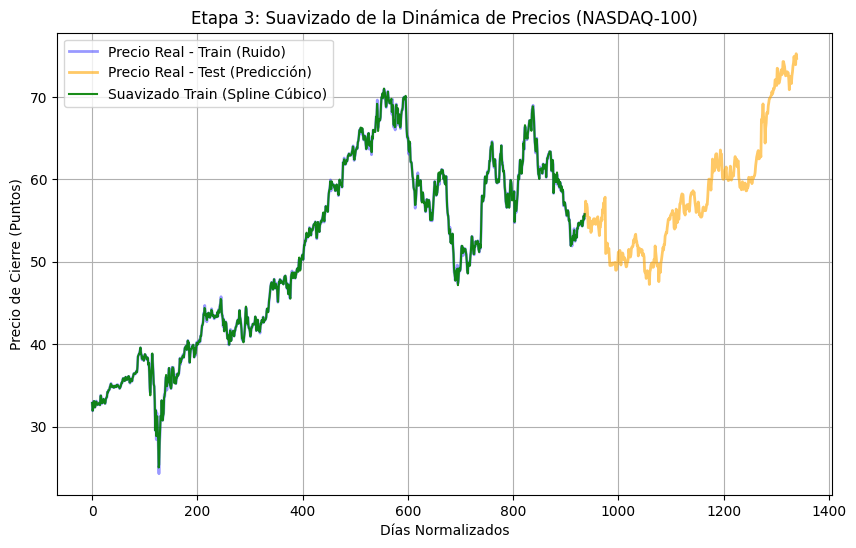

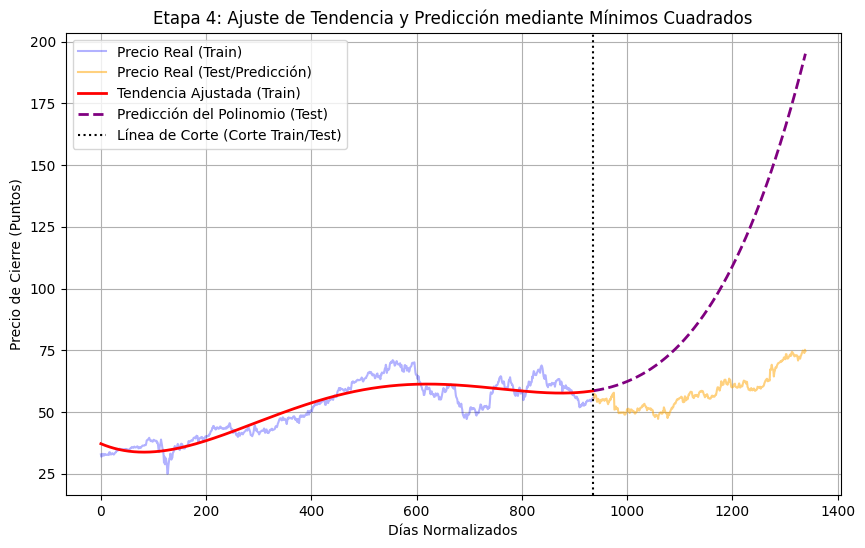

--- ETAPA 4: MODELO ENTRENADO ---
Polinomio de Grado: 4
Coeficiente de determinación R² (En Entrenamiento): 0.8315

No se detectó cambio de signo; se usa el último día como semilla.

--- ITERACIONES DEL MÉTODO DE NEWTON-RAPHSON ---
Iter  t_n            f(t_n)         t_n+1          Error       
1     1339.000000    110.056450     1208.603333    1.30e+02    
2     1208.603333    27.673200      1146.442101    6.22e+01    
3     1146.442101    4.480784       1131.803320    1.46e+01    
4     1131.803320    0.210046       1131.046828    7.56e-01    
5     1131.046828    0.000540       1131.044874    1.95e-03    
6     1131.044874    0.000000       1131.044874    1.30e-08    

Raíz encontrada: t* = 1131.0449 días hábiles
Verificación: P(t*) = 85.0000 (objetivo = 85)

Fecha estimada en la que el índice superaría los 85 puntos: 2024-01-31


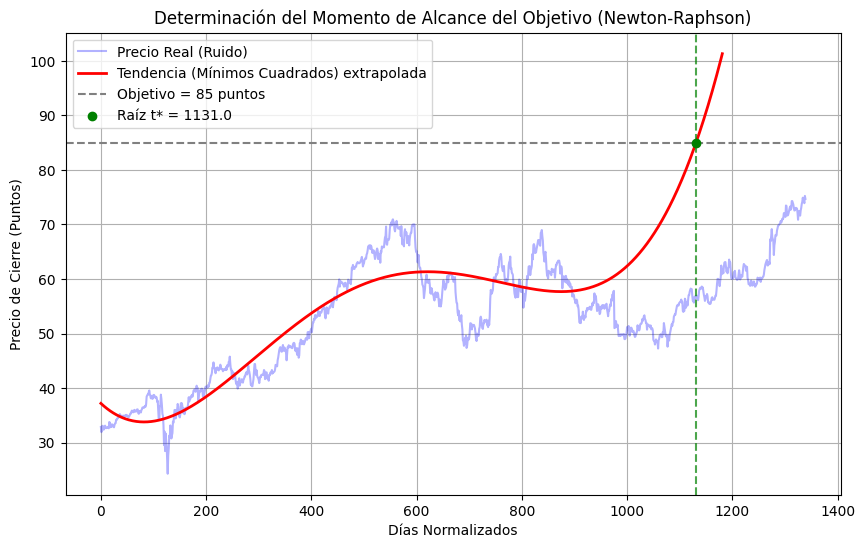

In [24]:
if __name__ == "__main__":
    # 1. Preparación de datos
    t_full_dataset, y_full_dataset, df_analisis_full = tratamiento_datos('/content/NASDAQ100.csv')

    # Manejar el caso en que el tratamiento de datos falle
    if t_full_dataset is None:
        print("El tratamiento de datos falló, saliendo.")
        exit()

    # 2. División del dataset (Train/Test)
    t_train, y_train, t_test, y_test = dividir_dataset(t_full_dataset, y_full_dataset, df_analisis_full)

    # 3. Suavizado con splines
    # La función splines toma t_train, y_train, t_test, y_test
    # y devuelve puntos densos del spline para el rango de entrenamiento (t_spline_dense, y_spline_dense).
    # También grafica los datos crudos de train/test y el spline.
    t_spline_dense, y_spline_dense = splines(t_train, y_train, t_test, y_test)

    # 4. Mínimos cuadrados
    # El polinomio se ajusta a la curva suavizada del spline (t_spline_dense, y_spline_dense)
    # pero también necesita los t_test y y_test originales para comparación y graficación.
    coefs, r_cuadrado = minimos_cuadrados(t_spline_dense, y_spline_dense, t_test, y_test, grado=4)

    # 5. Preparación para Newton - Raphson
    punto_objetivo = 85
    # Usar el máximo de la serie de tiempo original completa como punto de partida para la exploración.
    t_max_datos = t_full_dataset.max()

    # 6. Búsqueda de un intervalo con cambio de signo (acota la semilla t0)
    t_exploracion = np.linspace(t_max_datos, t_max_datos + 1500, 3000)
    valores_g = sum(coefs[i] * t_exploracion**i for i in range(len(coefs))) - punto_objetivo

    cambio_signo = np.where(np.diff(np.sign(valores_g)) != 0)[0]

    if len(cambio_signo) > 0:
        t0 = t_exploracion[cambio_signo[0]]
        print(f"\nCambio de signo detectado cerca de t = {t0:.2f}. Se usa como semilla inicial.")
    else:
        t0 = t_max_datos
        print("\nNo se detectó cambio de signo; se usa el último día como semilla.")

    # 7. Ejecución del método de Newton-Raphson
    t_raiz, historial = newton_raphson(coefs, punto_objetivo, t0)

    # 8. Tabla de iteraciones
    print("\n--- ITERACIONES DEL MÉTODO DE NEWTON-RAPHSON ---")
    print(f"{'Iter':<6}{'t_n':<15}{'f(t_n)':<15}{'t_n+1':<15}{'Error':<12}")
    for it in historial:
        print(f"{it[0]:<6}{it[1]:<15.6f}{it[2]:<15.6f}{it[3]:<15.6f}{it[4]:<12.2e}")

    print(f"\nRaíz encontrada: t* = {t_raiz:.4f} días hábiles")

    # Comprobación de la raíz (P(t*))
    valor_comprobacion = sum(coefs[i] * t_raiz**i for i in range(len(coefs)))
    print(f"Verificación: P(t*) = {valor_comprobacion:.4f} (objetivo = {punto_objetivo})")

    # 9. Conversión del resultado (t) a una fecha calendario
    primer_dia_dataset = df_analisis_full['Date'].iloc[0]
    fecha_estimada = primer_dia_dataset + pd.offsets.BDay(round(t_raiz))
    print(f"\nFecha estimada en la que el índice superaría los {punto_objetivo} puntos: {fecha_estimada.date()}")

    # 10. Visualización
    visualizar_proyeccion(t_full_dataset, y_full_dataset, coefs, punto_objetivo, t_raiz)